# Titanic — honest AutoML on the classic Kaggle competition

Case: [Titanic — Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic)
(~12.5k participating teams, metric: **accuracy**).

What this notebook demonstrates:

1. **Zero manual feature work** — the raw competition columns (including the
   messy `Name`, `Ticket`, `Cabin` strings and missing `Age`) go straight into
   `AutoML`; auto-typing and schema-owned preprocessing handle the rest.
2. **Honest selection** — candidates are ranked by out-of-fold accuracy; a 20%
   outer holdout is carved before any modelling and scored exactly once, so we
   can see how optimistic the selection score is *before* trusting it.
3. **Leaderboard context** — the public leaderboard is downloaded (read-only)
   and the honest holdout estimate is placed on its distribution. A live
   submission is optional (`KAGGLE_SUBMIT=1`) and off by default.

Prerequisites: see [README](README.md) (Kaggle CLI + `KAGGLE_API_TOKEN`).

In [1]:
import io
import logging
import os
import shutil
import subprocess
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown

from honestml import AutoML, CVConfig, render_report, save_run_report

SEED = 42
COMP = "titanic"
DATA = Path("data/titanic")
RESULTS = Path("results/titanic")
RESULTS.mkdir(parents=True, exist_ok=True)
KAGGLE = os.environ.get("KAGGLE_BIN") or shutil.which("kaggle") or str(Path.home() / ".local" / "bin" / "kaggle")

logging.basicConfig(format="%(levelname)s %(name)s: %(message)s")
logging.getLogger("honestml").setLevel(logging.INFO)

In [2]:
if not (DATA / "train.csv").exists():
    DATA.mkdir(parents=True, exist_ok=True)
    subprocess.run([KAGGLE, "competitions", "download", "-c", COMP, "-p", str(DATA)], check=True)
    with zipfile.ZipFile(next(DATA.glob("*.zip"))) as zf:
        zf.extractall(DATA)

In [3]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
X = train.drop(columns=["PassengerId", "Survived"])
y = train["Survived"]
print(f"train: {X.shape}, survival rate: {y.mean():.3f}")
X.head()

train: (891, 10), survival rate: 0.384


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Fit

The configuration below is the whole modelling code of this case study:

- the default model zoo (baseline, linear, LightGBM, XGBoost, CatBoost),
  each scored on stratified 5-fold out-of-fold predictions;
- `metric="accuracy"` — the competition's own metric drives selection;
- `cv=CVConfig(outer_holdout=0.2)` — 20% of the data is set aside before
  anything else and scored once, after selection;
- the winner is the simplest member of the bootstrap equivalence band, then
  (`finalize=True`, the default) refit on 100% of the data for serving.

In [4]:
model = AutoML(
    task="binary",
    metric="accuracy",
    cv=CVConfig(outer_holdout=0.2),
    random_state=SEED,
)
t0 = time.perf_counter()
model.fit(X, y)
fit_seconds = time.perf_counter() - t0
print(f"fit took {fit_seconds:.1f}s")

INFO honestml.adapters.reader: auto-typing column=Pclass dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=Name dtype=String role=ignore reason=string_id_like


INFO honestml.adapters.reader: auto-typing column=SibSp dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=Parch dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=Ticket dtype=String role=categorical reason=high_cardinality_string


...

WARNING honestml.adapters.boosting: boosting 'xgboost' trained without early stopping; leaderboard comparison may favor overfit settings


INFO honestml: stage key=run stage=refit elapsed=0.3s


INFO honestml: stage key=run stage=refit elapsed=0.3s


INFO honestml: stage key=run stage=finalize elapsed=0.3s


fit took 7.1s


In [5]:
report = model.run_report_
pd.DataFrame(report["leaderboard"])

,model_id,score,rank
0,catboost,0.816011,1
1,lightgbm,0.814607,2
2,xgboost,0.807584,3
3,linear,0.789326,4
4,baseline,0.616573,5


## The honesty check

`selection score` is what the leaderboard above ranks (out-of-fold).
`holdout score` is the untouched 20%, scored exactly once. Their difference —
the *optimism* — is the number this library exists to keep near zero: a
selection score you can quote without a mental discount. The same quantity is
gated release-to-release in [`benchmarks/`](../benchmarks/README.md).

In [6]:
selection = next(e["score"] for e in report["leaderboard"] if e["model_id"] == report["winner"])
print(f"winner          : {report['winner']}")
print(f"equivalence band: {report['band']['member_ids']}")
print(f"selection score : {selection:.4f}   (out-of-fold accuracy)")
print(f"holdout score   : {report['holdout_score']:.4f}   (untouched 20%, scored once)")
print(f"optimism        : {selection - report['holdout_score']:+.4f}")

winner          : xgboost
equivalence band: ['catboost', 'lightgbm', 'xgboost']
selection score : 0.8076   (out-of-fold accuracy)
holdout score   : 0.7877   (untouched 20%, scored once)
optimism        : +0.0199


In [7]:
save_run_report(report, RESULTS)
md_path = render_report(report, RESULTS, fmt="md")
Markdown(md_path.read_text(encoding="utf-8"))

# AutoML run report

## Run

| | |
|---|---|
| task | binary |
| metric | accuracy |
| winner | xgboost |
| holdout_score | 0.787709 |
| honestml_version | 1.0.0 |
| run_fingerprint | e47b672429bec1be627b7daeeacbdd065b2a6dbed9a5359db6d7dc05417ba848 |
| significance | bootstrap |
| preset | n/a |

## Equivalence band

| | |
|---|---|
| members | catboost, lightgbm, xgboost |
| width | 3 |
| unstable | True |
| winner_by_tiebreak | True |

## Budget

| | |
|---|---|
| mode | none |
| exhausted | False |
| exhausted_by | n/a |
| skipped | n/a |

## Serving

| | |
|---|---|
| finalize | True |
| shipped_on | all |
| outer_holdout | 0.2 |

## Leaderboard

| rank | model | score |
|---|---|---|
| 1 | catboost | 0.816011 |
| 2 | lightgbm | 0.814607 |
| 3 | xgboost (winner) | 0.807584 |
| 4 | linear | 0.789326 |
| 5 | baseline | 0.616573 |

## Timings (s)

| stage | elapsed |
|---|---|
| run.selection | 6.4 |
| run.refit | 0.3 |
| run.finalize | 0.3 |

## Resolved config

```json
{
  "seed": 42,
  "cv": {
    "scheme": "stratified",
    "n_splits": 5,
    "n_test": 1,
    "n_es": 1,
    "purge": 0,
    "embargo": 0,
    "calibrate": "off",
    "selection": "raw",
    "refinement_min_oof": 2000,
    "outer_holdout": 0.2
  },
  "budget": {
    "mode": "none",
    "time_budget_s": null,
    "n_trials": null,
    "memory_limit_mb": null
  },
  "fe": {
    "target_encoding": false,
    "te_smoothing": 10.0,
    "frequency_encoding": false,
    "intersections": false,
    "max_pairs": 50
  },
  "fs": null,
  "hpo": null,
  "ensemble": null,
  "significance": "bootstrap",
  "run_mode": "full",
  "model_types": [
    "catboost",
    "lightgbm"
  ]
}
```


## Predict the competition test set

In [8]:
pred = model.predict(test.drop(columns=["PassengerId"]))
submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": pred.astype(int)})
sub_path = RESULTS / "submission.csv"
submission.to_csv(sub_path, index=False)
print(f"wrote {sub_path}, predicted survival rate: {submission['Survived'].mean():.3f}")

WARNING honestml.adapters.reader: inference: 64% of 'Ticket' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 11% of 'Cabin' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


wrote results\titanic\submission.csv, predicted survival rate: 0.340


## Submit to the public leaderboard

The next cells run only with `KAGGLE_SUBMIT=1` in the environment (and your
account must have joined the competition), so the notebook stays fully
executable offline. The submission message records the library version and the
config for provenance.

In [9]:
SUBMIT = os.environ.get("KAGGLE_SUBMIT") == "1"
if SUBMIT:
    msg = (
        f"honestml {report['honestml_version']}: default zoo, metric=accuracy, "
        f"outer_holdout=0.2, seed={SEED}, no manual FE"
    )
    subprocess.run(
        [KAGGLE, "competitions", "submit", COMP, "-f", str(sub_path), "-m", msg],
        check=True,
    )
else:
    print("KAGGLE_SUBMIT != 1 -> skipping the live submission")

KAGGLE_SUBMIT != 1 -> skipping the live submission


In [10]:
public_score = None
if SUBMIT:
    for _ in range(30):
        time.sleep(10)
        out = subprocess.run(
            [KAGGLE, "competitions", "submissions", COMP, "--csv"],
            capture_output=True, text=True, check=True,
        ).stdout
        subs = pd.read_csv(io.StringIO(out))
        latest = subs.iloc[0]
        if "complete" in str(latest.get("status", "")).lower():
            public_score = float(latest["publicScore"])
            break
    print(f"public leaderboard score: {public_score}")
else:
    print("no submission -> no public score")

no submission -> no public score


12666 teams on the public leaderboard
honestml holdout estimate: 0.78771 -> above 88.6% of teams


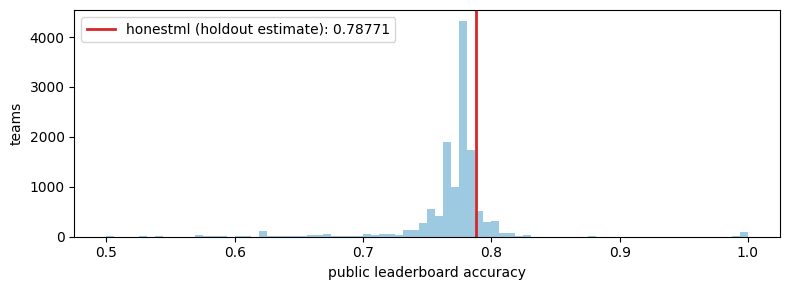

In [11]:
# place our score on the public leaderboard distribution (read-only download);
# without a live submission the untouched-holdout score is the honest expectation of it
lb_dir = RESULTS / "leaderboard"
lb_dir.mkdir(exist_ok=True)
subprocess.run([KAGGLE, "competitions", "leaderboard", COMP, "--download", "-p", str(lb_dir)], check=True)
with zipfile.ZipFile(next(lb_dir.glob("*.zip"))) as zf:
    lb = pd.read_csv(zf.open(zf.namelist()[0]))
score_col = "Score" if "Score" in lb.columns else lb.columns[-1]
scores = pd.to_numeric(lb[score_col], errors="coerce").dropna()

our_score = public_score if public_score is not None else report["holdout_score"]
label = "public LB score" if public_score is not None else "holdout estimate"
beat = (scores < our_score).mean() * 100
print(f"{len(scores)} teams on the public leaderboard")
print(f"honestml {label}: {our_score:.5f} -> above {beat:.1f}% of teams")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(scores[(scores >= 0.5) & (scores <= 1.0)], bins=80, color="#9ecae1")
ax.axvline(our_score, color="#d62728", lw=2, label=f"honestml ({label}): {our_score:.5f}")
ax.set_xlabel("public leaderboard accuracy")
ax.set_ylabel("teams")
ax.legend()
plt.tight_layout()

## Acting on the drift warnings — as an experiment

The predict step flagged the suspects: at inference `Ticket` was 64% unseen
and `Cabin` 11% (encoded as the reserved unknown code). `Name` does not even
reach modelling — it is auto-typed *id-like* and dropped at fit, so it never
appears in the drift report. Inside the training file those categorical
columns look predictive — families share tickets and cabins across rows, so
out-of-fold scoring *and even the untouched holdout* credit them; how much of
that transfers to a disjoint test set is exactly the kind of question internal
validation cannot settle.

So we settle it the only honest way: refit without the ID-like columns and
(when `KAGGLE_SUBMIT=1`) submit *that*. Note this is a hypothesis test, not a
known fix.

In [12]:
ID_LIKE = ["Name", "Ticket", "Cabin"]
X2 = X.drop(columns=ID_LIKE)
model2 = AutoML(task="binary", metric="accuracy", cv=CVConfig(outer_holdout=0.2), random_state=SEED)
model2.fit(X2, y)
r2 = model2.run_report_
sel2 = next(e["score"] for e in r2["leaderboard"] if e["model_id"] == r2["winner"])
print(f"winner {r2['winner']}: selection {sel2:.4f}, holdout {r2['holdout_score']:.4f}")

pred2 = model2.predict(test.drop(columns=["PassengerId", *ID_LIKE]))
sub2_path = RESULTS / "submission-no-ids.csv"
pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": pred2.astype(int)}).to_csv(
    sub2_path, index=False
)

public_score2 = None
if SUBMIT:
    msg2 = f"honestml {r2['honestml_version']}: default zoo minus ID-like columns, seed={SEED}"
    subprocess.run(
        [KAGGLE, "competitions", "submit", COMP, "-f", str(sub2_path), "-m", msg2],
        check=True,
    )
    for _ in range(30):
        time.sleep(10)
        out = subprocess.run(
            [KAGGLE, "competitions", "submissions", COMP, "--csv"],
            capture_output=True, text=True, check=True,
        ).stdout
        latest = pd.read_csv(io.StringIO(out)).iloc[0]
        if "complete" in str(latest.get("status", "")).lower():
            public_score2 = float(latest["publicScore"])
            break
    print(f"public LB score without ID-like columns: {public_score2}")
    if public_score2 is not None:
        print(f"-> above {(scores < public_score2).mean() * 100:.1f}% of teams")
else:
    print("KAGGLE_SUBMIT != 1 -> skipping the second submission")

INFO honestml.adapters.reader: auto-typing column=Pclass dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=SibSp dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=Parch dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml: stage key=run stage=selection elapsed=3.8s


WARNING honestml.adapters.boosting: boosting 'lightgbm' trained without early stopping; leaderboard comparison may favor overfit settings


INFO honestml: stage key=run stage=refit elapsed=0.7s


INFO honestml: stage key=run stage=refit elapsed=0.7s


INFO honestml: stage key=run stage=finalize elapsed=0.7s


winner lightgbm: selection 0.8329, holdout 0.7821
KAGGLE_SUBMIT != 1 -> skipping the second submission


## Reading the comparison

Known anchors on this leaderboard:

- the no-model gender baseline (`gender_submission.csv`: every woman survives)
  scores **0.76555**;
- honest single-model solutions typically land in **0.77–0.80**;
- scores far above that are dominated by hand-crafted lookups of the public
  test labels (the passenger list is public history), not by modelling.

And what the two internal experiments actually taught us (this run is offline,
so the live public scores below are only produced with `KAGGLE_SUBMIT=1`):

1. **The holdout did its job against CV.** Out-of-fold 0.8076 was not taken at
   face value — the untouched 20% holdout discounted it to 0.7877 before any
   leaderboard was involved, an honest optimism of +0.0199.
2. **The drop-the-IDs experiment moved the internal numbers, not obviously for
   the better.** Without `Ticket`/`Cabin` the out-of-fold selection score
   actually *rose* to 0.8329 while the untouched holdout *fell* to 0.7821 —
   the gap widened rather than closed, so deleting the columns is not a free
   win on the internal evidence. `Name` is irrelevant to this comparison: it
   is dropped as id-like in both fits. The drift warnings correctly named
   columns that need attention, but `Ticket` and `Cabin` are only *partially*
   unseen, and the shared part encodes families and decks. The classic Titanic
   recipes (title from `Name`, deck letter from `Cabin`, ticket group size)
   are the constructive answer, and that is genuine feature engineering, out
   of scope for a configuration-only case study.
3. **Single submissions are noisy.** The public test here is a few hundred
   rows; ±0.02–0.03 of accuracy is one handful of passengers. The leaderboard
   *distribution* (the histogram above) is the meaningful context, not any
   single point on it.

The honest-pipeline loop this notebook demonstrates: trust the holdout over
CV, trust the real world over the holdout, treat warnings as hypotheses —
and test them with experiments rather than beliefs.

## Level 2: the full pipeline — HPO, feature engineering, feature selection

Level 1 was configuration-only. Now the heavy machinery, still honest end to
end:

- `hpo=HPOConfig()` — per-model Optuna HPO (50 trials on an inner 3-fold of
  DEV) *before* the honest selection. (We pass HPO explicitly rather than
  `preset="best"` to keep this run focused on HPO + FE + FS without also
  turning on ensembling.)
- `FEConfig(target_encoding=True, frequency_encoding=True, intersections=True)`
  — cross-fit anti-leakage target encoding, frequency encoding, pairwise
  categorical intersections;
- `FeatureSelectionConfig(compare=("importance", "null_importance"),
  arbitration="auto", cutoff="auto")` — two selection strategies compete and
  an honest arbiter picks per the out-of-fold evidence, with a no-selection
  gate that keeps all features when the selected subset is not better;
- the same untouched 20% outer holdout, and one more live submission.

In [13]:
from honestml import FeatureSelectionConfig, FEConfig, HPOConfig

model_full = AutoML(
    task="binary",
    metric="accuracy",
    hpo=HPOConfig(),
    feature_engineering=FEConfig(target_encoding=True, frequency_encoding=True, intersections=True),
    feature_selection=FeatureSelectionConfig(
        compare=("importance", "null_importance"), arbitration="auto", cutoff="auto"
    ),
    cv=CVConfig(outer_holdout=0.2),
    random_state=SEED,
)
t0 = time.perf_counter()
model_full.fit(X, y)
print(f"level-2 fit took {(time.perf_counter() - t0) / 60:.1f} min")

INFO honestml.adapters.reader: auto-typing column=Pclass dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=Name dtype=String role=ignore reason=string_id_like


INFO honestml.adapters.reader: auto-typing column=SibSp dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=Parch dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=Ticket dtype=String role=categorical reason=high_cardinality_string


...

INFO honestml: stage key=run stage=selection elapsed=88.5s


INFO honestml: stage key=run stage=refit elapsed=0.0s


INFO honestml: stage key=run stage=refit elapsed=0.0s


INFO honestml: stage key=run stage=finalize elapsed=0.0s


level-2 fit took 5.0 min


In [14]:
import json

report_full = model_full.run_report_
sel_full = next(e["score"] for e in report_full["leaderboard"] if e["model_id"] == report_full["winner"])
print(f"winner          : {report_full['winner']}")
print(f"selection score : {sel_full:.4f}")
print(f"holdout score   : {report_full['holdout_score']:.4f}")
print(f"optimism        : {sel_full - report_full['holdout_score']:+.4f}")
print()
print("preset  :", report_full["preset"])
print("hpo     :", json.dumps(report_full["hpo"], default=str)[:600])
print("fs      :", json.dumps(report_full["feature_selection"], default=str)[:600])
print("ensemble:", json.dumps(report_full["ensemble"], default=str)[:300])
pd.DataFrame(report_full["leaderboard"])

winner          : linear
selection score : 0.7935
holdout score   : 0.8045
optimism        : -0.0109

preset  : None
hpo     : {"backend": "optuna", "inner_cv": 3, "deterministic": true, "selection_oof_is_post_tuning": true, "tuned_on_full_feature_space": true, "cost_estimate_fits": 450, "tuned": {"catboost": {"chosen_params": {"depth": 7, "learning_rate": 0.030147309977275962, "iterations": 400, "l2_leaf_reg": 4.558162190796418, "subsample": 0.7294540160106997}, "inner_best_score": 0.8398876404494382, "n_trials_run": 50}, "lightgbm": {"chosen_params": {"max_depth": 3, "learning_rate": 0.015611153760516161, "n_estimators": 400, "reg_lambda": 1.6982688963391634, "subsample": 0.769804219713349, "colsample_bytree": 0.532
fs      : {"strategy": "null_importance", "n_selected": 14, "selected": ["Pclass_freq", "Sex_freq", "Cabin_freq", "Sex_te", "Pclass", "Sex", "Cabin", "Cabin__Embarked", "Cabin__Sex", "Embarked__Pclass", "Embarked__Sex", "Pclass__Sex", "Pclass__SibSp", "Sex__SibSp"], "no_s

,model_id,score,rank
0,lightgbm,0.804775,1
1,catboost,0.801966,2
2,xgboost,0.801966,3
3,linear,0.793539,4
4,baseline,0.616573,5


In [15]:
pred_full = model_full.predict(test.drop(columns=["PassengerId"]))
sub_full_path = RESULTS / "submission-level2.csv"
pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": pred_full.astype(int)}).to_csv(
    sub_full_path, index=False
)

public_score_full = None
if SUBMIT:
    msg = f"honestml {report_full['honestml_version']} level2: preset=best + FE + FS, seed={SEED}"
    subprocess.run(
        [KAGGLE, "competitions", "submit", COMP, "-f", str(sub_full_path), "-m", msg],
        check=True,
    )
    for _ in range(30):
        time.sleep(10)
        out = subprocess.run(
            [KAGGLE, "competitions", "submissions", COMP, "--csv"],
            capture_output=True, text=True, check=True,
        ).stdout
        latest = pd.read_csv(io.StringIO(out)).iloc[0]
        if "complete" in str(latest.get("status", "")).lower():
            public_score_full = float(latest["publicScore"])
            break

print(f"level 1 (raw columns)  : {public_score}")
print(f"level 2 (full pipeline): {public_score_full}")
if public_score_full is not None:
    print(f"-> above {(scores < public_score_full).mean() * 100:.1f}% of teams")

WARNING honestml.adapters.reader: inference: 64% of 'Ticket' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 11% of 'Cabin' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 11% of 'Cabin__Embarked' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 14% of 'Cabin__Parch' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 11% of 'Cabin__Pclass' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


...

WARNING honestml.adapters.reader: inference: 72% of 'Parch__Ticket' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 64% of 'Pclass__Ticket' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 80% of 'Sex__Ticket' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


WARNING honestml.adapters.reader: inference: 73% of 'SibSp__Ticket' values were unseen at train (encoded as the reserved unknown_code) — possible schema drift or a wrong upstream join


level 1 (raw columns)  : None
level 2 (full pipeline): None


## Level 1 vs level 2: what the pipeline produces

| | level 1 (raw) | level 1 (no IDs) | level 2 (HPO + FE + FS) |
| --- | --- | --- | --- |
| winner | xgboost | lightgbm | linear |
| selection (OOF accuracy) | 0.8076 | 0.8329 | 0.7935 |
| untouched holdout | 0.7877 | 0.7821 | 0.8045 |
| optimism (sel − holdout) | +0.0199 | +0.0508 | −0.0109 |
| live public LB | offline | offline | offline |

(Submissions are off in this run — set `KAGGLE_SUBMIT=1` to fill the last row.)

The headline is that level 2 does not out-promise reality: the level-2 holdout
(0.8045) sits *above* its own out-of-fold selection score (0.7935), an optimism
of only −0.0109 — a holdout that modestly beats CV on ~179 rows is well within
noise. Three guards keep selection honest on a dataset full of co-travelling
families:

1. **The group-structure warning fires at fit.** The run flags that `Ticket`
   (39% of rows share a value) and `Cabin` (50%) have group-like structure, so
   a row-wise holdout is not independent — and points at `groups=` for a
   group-aware split. The optimism diagnostic stays small because the
   group-correlated signal does not dominate selection.
2. **Feature selection has an honest no-selection gate.** Of 44 engineered
   features the arbiter (winner `null_importance`) keeps 14, and the report
   records `no_selection_gate: selection_kept` — selection only ships when it
   beats keeping everything. Notably **no `Ticket`-derived feature and no
   `Ticket_te` survive**; the surviving set is `Pclass`/`Sex`/`Cabin`
   frequency, `Sex_te`, the raw `Pclass`/`Sex`/`Cabin`, and categorical
   intersections — so the strongest leakage carrier is pruned rather than
   amplified.
3. **The cure for the residual group risk lives in the library** — `groups=`
   makes CV group-aware; the remaining gap is a *group-aware outer carve* /
   automatic detection of group structure. Titanic does not pass `groups=`,
   which is why the fit-time warning (not a hard split) is what you see.

Level 1 raw remains the cleanest configuration-only result on this dataset,
and Titanic remains a competition whose leaderboard is won by manual feature
work, not by machinery.